In [1]:
# Import core libraries and NUGGET modules
import torch
import numpy as np
import nugget  # Main NUGGET package for neutrino detector optimization
import matplotlib.pyplot as plt
import importlib
import pickle
import os
from nugget.geometries.base_geometry import compare_geometries
from scipy.spatial.distance import squareform
# from sklearn.manifold import MDS
import time
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score, roc_curve
import sys
import pandas as pd
from scipy import stats
from scipy.integrate import cumulative_trapezoid

[KeOps] Warning : CUDA libraries not found or could not be loaded; Switching to CPU only.


In [2]:
os.environ['OMP_NUM_THREADS'] = '1'
os.environ['MKL_NUM_THREADS'] = '1'
os.environ['OPENBLAS_NUM_THREADS'] = '1'

In [2]:
device = 'cuda:0'
importlib.reload(nugget.surrogates.LightSabre)
patd_surrogate = nugget.surrogates.LightSabre.LightSabrePATD(
        device=device,
        use_poisson=False,
        num_track_points=1000,
        domain_size=2000,
        use_max_energy_dist=True,
        use_perpendicular_distance_only=True,
        particle_mode='track',
        )
light_yield_surrogate_patd = patd_surrogate.light_yield_surrogate
lightsabre = nugget.surrogates.LightSabre.LightSabre(
                device=device,
                use_poisson=False, 
                num_track_points=2000, 
                domain_size=2000,
                particle_mode='track',
                )
light_yield_surrogate = lightsabre.light_yield_surrogate
batched_light_yield_surrogate = lightsabre.light_yield_surrogate_batched

signal_sampler = nugget.samplers.cyl_sampler.CylinderSampler(
        device=device,
        event_type='signal',
        domain_size=2000,
        E_min=1e2,
        E_max=1e8,
        energy_dist='log_uniform',
        find_exact_intersection=False,
        random_position_along_ray=False,
        box_intersection=True,
        uniform_zenith_sampling=True,
        )

In [3]:
importlib.reload(nugget.surrogates.LLRnet)

llr_net = nugget.surrogates.LLRnet.LLRnet(
    device=device,
    domain_size=2500,
    dim=3,
    hidden_dims=[64, 64, 64, 64, 64, 64],
    use_fourier_features=False,
    num_parallel_branches=1,
    learnable_frequencies=False,
    dropout_rate=0.05,
    learning_rate=3e-4,
    shared_mlp=False,
    use_residual_connections=True,
    signal_noise_scale=0,
    background_noise_scale=0,
    # add_relative_pos / log_scale_ly / norm_pos / log_scale_energy are unused
    # when use_rich_features=True; prepare_features_patd handles normalisation internally.
    add_relative_pos=False,
    log_scale_ly=True,
    norm_pos=True,
    log_scale_energy=True,
    
    reduce_lr_on_plateau=True,
    lr_scheduler_patience=30,
    lr_scheduler_factor=0.5,
    lr_scheduler_min_lr=1e-6,
    min_photons=1,
    num_photons_per_sample=None,
    input_charge=False,
    rel_time=True,
    input_delta_time=False,  # residual time is baked into prepare_features_patd as t_geom_min
    use_rich_features=True,
    add_distance_from_beam=False,
    use_patd=False,
    add_vertex_distance=True,
)

# llr_net.load_model('llrnet_models/best_hit_llr_model_v8.pt')
# llr_net.load_model('llrnet_models/best_charge_llr_model_v5.pt')
llr_net.load_model('llrnet_models/best_mc_ly_muon_llr_model_v7.pt')
# history = pickle.load(open('hit_llr_v7_training_history.pkl', 'rb'))
# history = pickle.load(open('charge_llr_v5_training_history.pkl', 'rb'))
# marginalised_ly = torch.load('llrnet_models/charge_llr_v6_training_ly.pt')

Building parallel network architecture:
  Input dim: 16
  Number of parallel branches: 1
  Shared MLP: False
  Branch 0 MLP with residual connections: 16 -> [250, 250, 250, 250, 250, 250, 250, 250, 250, 250, 250, 250, 250, 250, 250] -> 250
  Final MLP: 250 -> 64 -> 1
  Total trainable parameters: 961,629


In [ ]:
parquet_path = "new_accepted_photons_ly_all.parquet"   # <-- your parquet
geometry_csv_path = "../other/800_40_40_geom.csv"     # <-- your geometry CSV

# ---- 1. Build the dataset once (gives us rows + event_data builder) ----
#     add_pmt_direction / uniform_energy_zenith etc. are read from the model as usual.
ds = llr_net.LightYieldParquetDataset(
    llrnet_instance=llr_net,
    parquet_path=parquet_path,
    geometry_csv_path=geometry_csv_path,
    seed=None,
    filter_vertex_in_domain=True,
)

In [29]:
importlib.reload(nugget.utils.vis_tools)
# for det_points in range(0,51, 5):
result = nugget.utils.vis_tools.plot_nll_landscape(
    llrnet=llr_net,
    signal_sampler=signal_sampler,
    signal_surrogate_func=light_yield_surrogate_patd,
    event_labels=['position','energy', 'direction'],
    param_names =['zenith','azimuth'],
    # param_names=['energy'],
    # param_ranges={'energy': (1e2, 1e8)},
    param_ranges={'energy': (1e2, 1e8), 'zenith': (0, np.pi), 'azimuth': (0, 2*np.pi)},
    # param_names=['x', 'y'],
    # param_ranges={'x': (-3, 3), 'y': (-3, 3)},
    figsize=(7,5),
    n_points=30,
    detector_point=None,   
    # true_event=true_event,
    use_mollweide=True,
    skip_zero_response=True,
    use_patd = False,
    use_rich_features = True,
    num_detector_points=1000, 
    min_detector_points=50,
    min_detector_response=1.0, 
    max_detector_resample_attempts=100000,
    plot_opposite_direction_true_params=True,
    progress_print_every_n_points=30   ,
    parquet_dataset=ds,
    # nll_cbar_max=550 
)
    # fig = result['fig']
    # fig.savefig(f"llr_landscape_detpoints_{det_points}.png", dpi=300, bbox_inches='tight')

plot_nll_landscape: using parquet event (397, 50) with 35/35 hit PMT(s).
  neutrino energy : 271.6 GeV
  zenith          : 1.7087 rad (cos = -0.1374)
  azimuth         : 4.5303 rad
  muon vertex     : (-402.10, -1240.44, -295.58) m
  light yields    : min 1.0, max 2.0, sum 40.0


RuntimeError: mat1 and mat2 shapes cannot be multiplied (35x12 and 16x250)

In [45]:
from pathlib import Path
import re
import imageio.v3 as iio

# Build a GIF from saved frames: llr_landscape_detpoints_*.png
frames_dir = Path(".")
pattern = "llr_landscape_detpoints_*.png"
output_gif = frames_dir / "llr_landscape_detpoints.gif"
fps = 2

image_paths = list(frames_dir.glob(pattern))

if not image_paths:
    raise FileNotFoundError(f"No images found matching pattern: {pattern}")

def _extract_det_points(path: Path) -> int:
    match = re.search(r"detpoints_(\d+)", path.name)
    return int(match.group(1)) if match else 10**9

image_paths = sorted(image_paths, key=_extract_det_points)
frames = [iio.imread(p) for p in image_paths]

# duration is in milliseconds per frame for imageio.v3.imwrite with .gif
frame_duration_ms = int(round(1000 / fps))
iio.imwrite(output_gif, frames, duration=frame_duration_ms, loop=0)

print(f"Saved GIF: {output_gif.resolve()}")
print(f"Frames used ({len(image_paths)}):")
for p in image_paths:
    print(f"  - {p.name}")

Saved GIF: /ptmp/mpp/kristiantcho/nugget/nugget/examples/llr_landscape_detpoints.gif
Frames used (11):
  - llr_landscape_detpoints_0.png
  - llr_landscape_detpoints_5.png
  - llr_landscape_detpoints_10.png
  - llr_landscape_detpoints_15.png
  - llr_landscape_detpoints_20.png
  - llr_landscape_detpoints_25.png
  - llr_landscape_detpoints_30.png
  - llr_landscape_detpoints_35.png
  - llr_landscape_detpoints_40.png
  - llr_landscape_detpoints_45.png
  - llr_landscape_detpoints_50.png


In [4]:


# ---- config ----
# parquet_path = "new_accepted_photons_ly_all.parquet"   # <-- your parquet
parquet_path = "./llrnet_models/mc_ly_muon_llr_v7_test_samples.parquet"   # <-- your parquet
geometry_csv_path = "../other/800_40_40_geom.csv"     # <-- your geometry CSV
device       = llr_net.device

# ---- 1. Build the dataset once (gives us rows + event_data builder) ----
#     add_pmt_direction / uniform_energy_zenith etc. are read from the model as usual.
ds = llr_net.LightYieldParquetDataset(
    llrnet_instance=llr_net,
    parquet_path=parquet_path,
    geometry_csv_path=geometry_csv_path,
    seed=None,
    filter_vertex_in_domain=True
)



# # ---- 3. Marginalized LY PDF from the LLRnet built-in (LY >= 1, log-interpolated) ----
# pdf_fit = llr_net.compute_light_yield_pdf(parquet_path, geometry_csv_path)
# marginal_pdf = pdf_fit['pdf']                        # callable: linear LY -> density




LightYieldParquetDataset: dropped 53256 row(s) with muon vertex outside domain half-extents [4000.0, 4000.0, 4000.0].


Picked row 3380: true LY = 574.0, E_nu = 6.45e+05 GeV, zenith = 0.239 rad


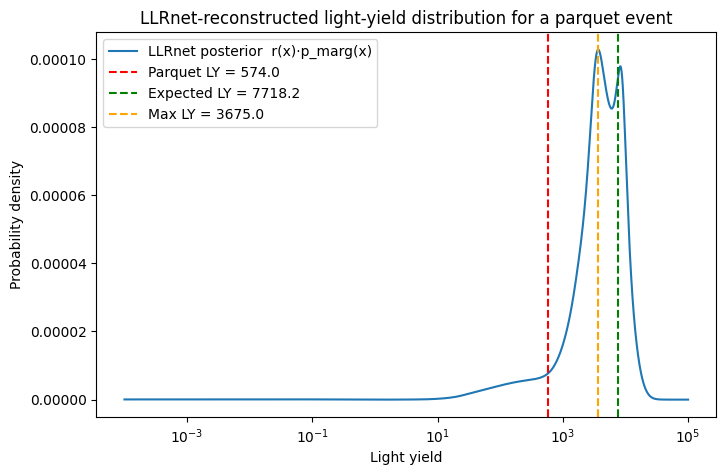

Parquet LY:  574.00
Expected LY: 7718.16
Ratio expected/true: 13.45


In [10]:
charge_floor = 1e-3                     # marginal PDF is built for LY >= 1
charge_ceil  = 1e5
n_grid       = 10000
true_charge =0
# ---- 2. Pick a random row (event + its light yield) from the parquet ----
while true_charge < 100:    
    rng = np.random.default_rng(None)
    row = int(rng.integers(0, ds._n_rows))
    true_charge = float(ds._count[row])                 # the LY recorded at this PMT
event_data  = ds._event_data(row)                   # matches training features exactly
point       = torch.tensor(ds._point[row], device=device, dtype=torch.float32)  # OM position
print(f"Picked row {row}: true LY = {true_charge:.1f}, "
      f"E_nu = {ds._energy[row]:.3g} GeV, zenith = {ds._zenith[row]:.3f} rad")

# ---- 4. Likelihood profile over a log-spaced LY grid ----
log_lo = np.log10(0.0001)
log_hi = np.log10(charge_ceil)
test_charges = torch.logspace(log_lo, log_hi, steps=n_grid, device=device)

likelihoods = []
for tc in test_charges:
    feats = llr_net.prepare_features_charge(point=point, event_data=event_data, light_yield=tc)
    likelihoods.append(llr_net.predict_likelihood_ratio(feats))
likelihoods = torch.stack(likelihoods).squeeze(-1).detach().cpu()   # r(x) = p(x|theta)/p_marg(x)

# ---- 5. Reconstruct p(LY | event) = r(x) * p_marginal(x), then normalize ----
x_np      = test_charges.detach().cpu().numpy()
# marg_dens = torch.tensor(marginal_pdf(x_np), dtype=torch.float64)
# marg_dens = marg_dens / torch.trapz(marg_dens, test_charges.detach().cpu().to(torch.float64))
# posterior = likelihoods.to(torch.float64)* marg_dens
posterior = likelihoods.to(torch.float64) 
posterior = posterior / torch.trapz(posterior, test_charges.detach().cpu().to(torch.float64))

# ---- 6. Expected LY under the reconstructed distribution ----
xc = test_charges.detach().cpu().to(torch.float64)
expected_ly = torch.trapz(xc * posterior, xc).item()
max_ly = xc[torch.argmax(posterior)].item()
# ---- 7. Plot ----
plt.figure(figsize=(8, 5))
plt.plot(x_np, posterior.numpy(), label='LLRnet posterior  r(x)·p_marg(x)', color='tab:blue')
plt.axvline(true_charge,  color='red',  ls='--', label=f'Parquet LY = {true_charge:.1f}')
plt.axvline(expected_ly,  color='green', ls='--', label=f'Expected LY = {expected_ly:.1f}')
plt.axvline(max_ly, color='orange', ls='--', label=f'Max LY = {max_ly:.1f}')
plt.xscale('log')
plt.xlabel('Light yield')
plt.ylabel('Probability density')
plt.legend()
plt.title('LLRnet-reconstructed light-yield distribution for a parquet event')
plt.show()

print(f"Parquet LY:  {true_charge:.2f}")
print(f"Expected LY: {expected_ly:.2f}")
print(f"Ratio expected/true: {expected_ly / true_charge:.2f}")

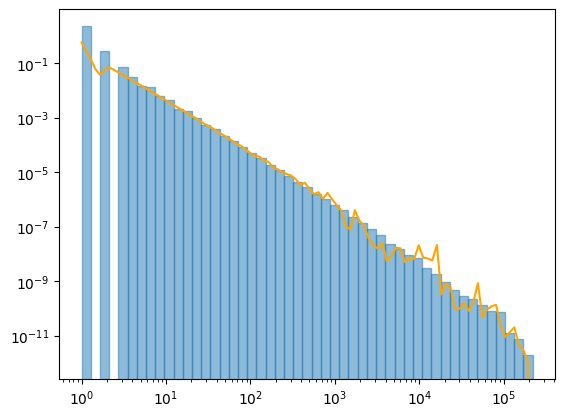

In [21]:
# pdf_fit = llr_net.compute_light_yield_pdf(parquet_path, geometry_csv_path, num_points=30)
# marginal_pdf = pdf_fit['pdf']   
bins = np.logspace(np.log10(pdf_fit['values'].min()), np.log10(pdf_fit['values'].max()), 50)
plt.hist(pdf_fit['values'], bins=bins, weights=pdf_fit['weights'], density=True, label='PDF', color='tab:blue', alpha=0.5, fill=True, edgecolor='tab:blue')
scatter_points = np.logspace(np.log10(pdf_fit['values'].min()), np.log10(pdf_fit['values'].max()), 100)
plt.plot(scatter_points, pdf_fit['pdf'](scatter_points), label='Fitted PDF', color='orange')
plt.xscale('log')
plt.yscale('log')

In [24]:
# --- marginal as a PMF; no density fit ---
vals, wts = ds.light_yield_value_counts(include_zeros=False)
keep = vals >= 1.0
vals, wts = vals[keep].astype(np.float64), wts[keep].astype(np.float64)
log_pmf = np.log(wts / wts.sum())

# --- one batched forward pass over every candidate q ---
B = len(vals)
rep = lambda a: np.repeat(a[None, :], B, axis=0)
feats = llr_net.prepare_features_charge_rows(
    points=rep(ds._point[row]), vertices=rep(ds._muon_pos[row]),
    energies=np.full(B, ds._energy[row]), zeniths=np.full(B, ds._zenith[row]),
    azimuths=np.full(B, ds._azimuth[row]), light_yields=vals,
    pmt_directions=rep(ds._pmt_direction[row]), device=llr_net.device)
log_r = llr_net.predict_log_likelihood_ratio(feats).detach().cpu().numpy().ravel()

# --- conditional PMF, normalised in log space (no overflow, no lost atom) ---
log_p = log_r + log_pmf
log_p -= log_p.max()
p = np.exp(log_p); p /= p.sum()

expected_ly = float((vals * p).sum())
mode_ly     = float(vals[p.argmax()])

In [27]:
vals, wts

(array([1.0000e+00, 2.0000e+00, 3.0000e+00, ..., 7.1097e+04, 7.6455e+04,
        8.2694e+04], shape=(1365,)),
 array([7.47506e+05, 1.47234e+05, 6.12360e+04, ..., 1.00000e+00,
        1.00000e+00, 1.00000e+00], shape=(1365,)))